# GeoBench SpaceNet2

## Intro

SpaceNet2 [(van Etten et al. 2018)](https://arxiv.org/abs/1807.01232) is a building footprint extraction dataset using high-resolution satellite imagery from diverse global urban areas. The dataset provides very high-resolution optical imagery with precise building footprint annotations, enabling automated building detection and mapping for urban planning, disaster response, and infrastructure monitoring. It addresses the critical challenge of accurate building extraction across diverse architectural styles and urban development patterns.

## Dataset Characteristics

- **Modalities**: 
  - Very high-resolution satellite imagery
- **Spatial Resolution**: 0.3m (pan-sharpened)
- **Temporal Resolution**: Single acquisition per location
- **Spectral Bands**: 
  - RGB: 3 channels (Red, Green, Blue)
- **Image Dimensions**: 512x512 pixels per patch
- **Labels**:
  - Binary segmentation (building vs. non-building)
- **Geographic Distribution**: Global urban areas (Las Vegas, Paris, Shanghai, Khartoum)

## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Split Generation**:
   - For each of the four different AOIs, we chose a checkerboard style split, where the area extent over each AOI is overlaid with a grid (checkerboard) that determines which samples belong to each grid cell. Each grid cell is then either assigned to train/val/test such that the percentage distribution is roughly 70/10/20 across train/val/test

2. **Dataset Subsampling**:
    - The final version consists of
        - 4,000 training samples
        - 1,000 validation samples
        - 2,000 test samples

## References

1. Van Etten, A., Lindenbaum, D. and Bacastow, T.M., 2018. Spacenet: A remote sensing dataset and challenge series. arXiv preprint https://arxiv.org/abs/1807.01232

In [1]:
import os
from pathlib import Path

import torch
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

from geobench_v2.datamodules import GeoBenchSpaceNet2DataModule
from geobench_v2.datasets import GeoBenchSpaceNet2
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/spacenet2")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "spacenet2_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "spacenet2_stats_clip_rescale.json")

In [3]:
band_order = GeoBenchSpaceNet2.band_default_order

datamodule = GeoBenchSpaceNet2DataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


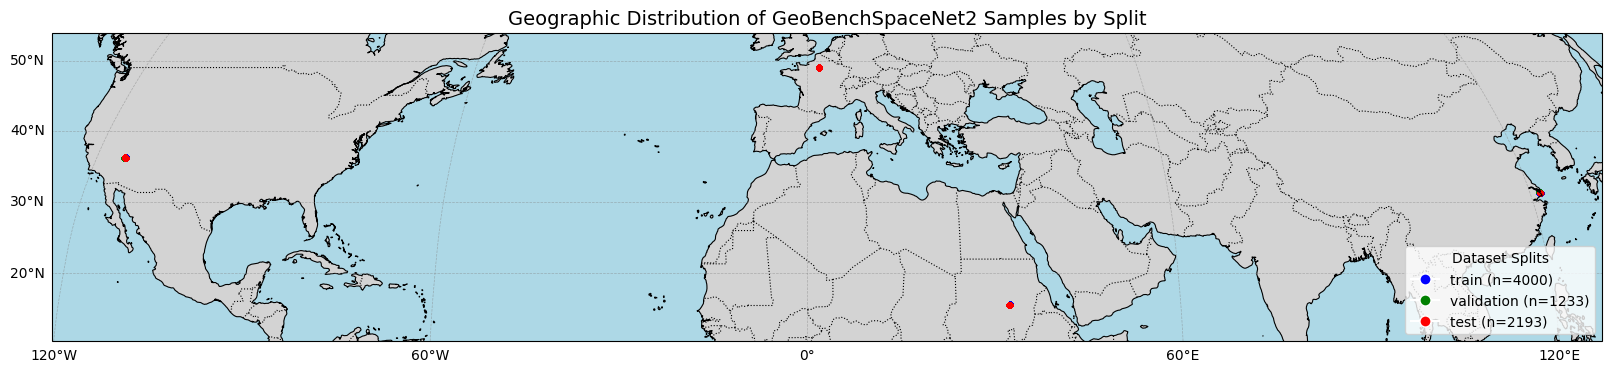

In [4]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Statistics

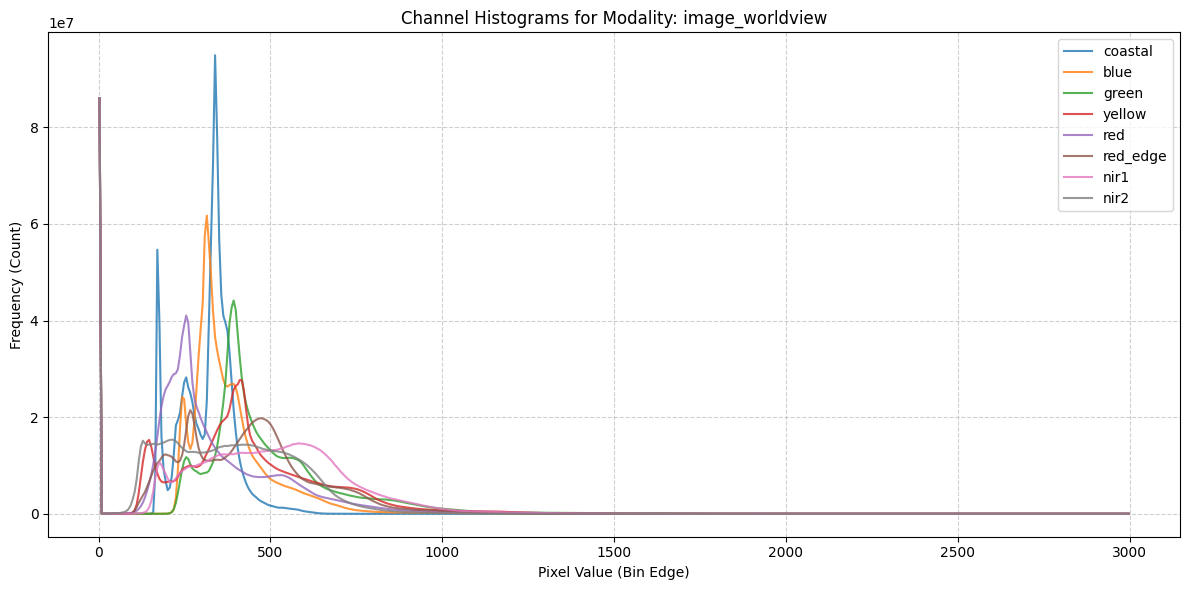

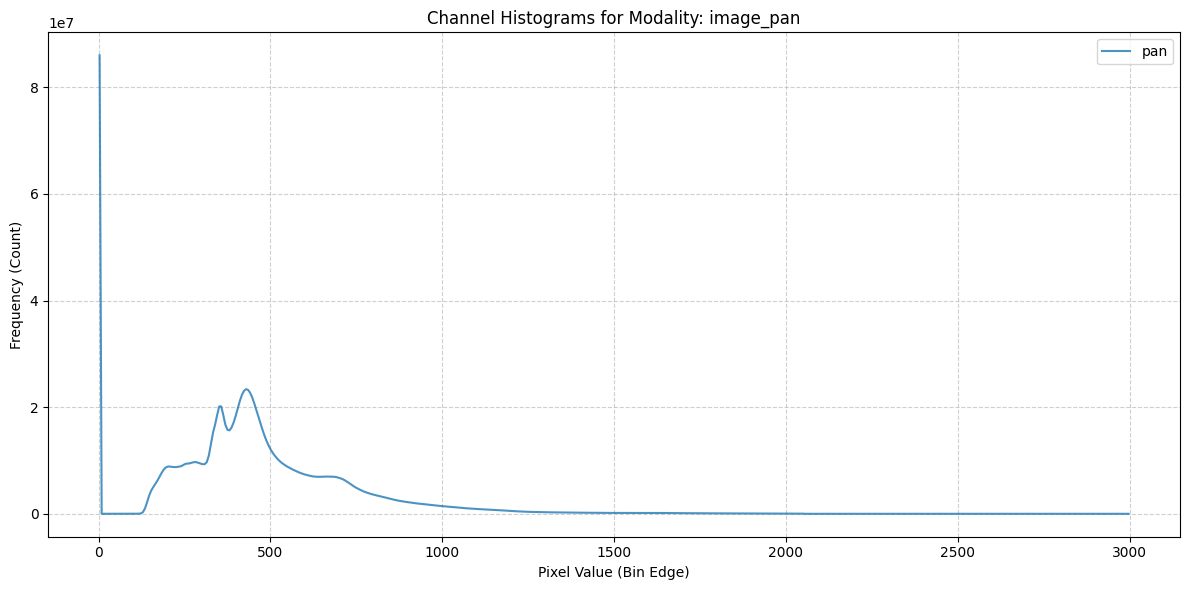

In [5]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

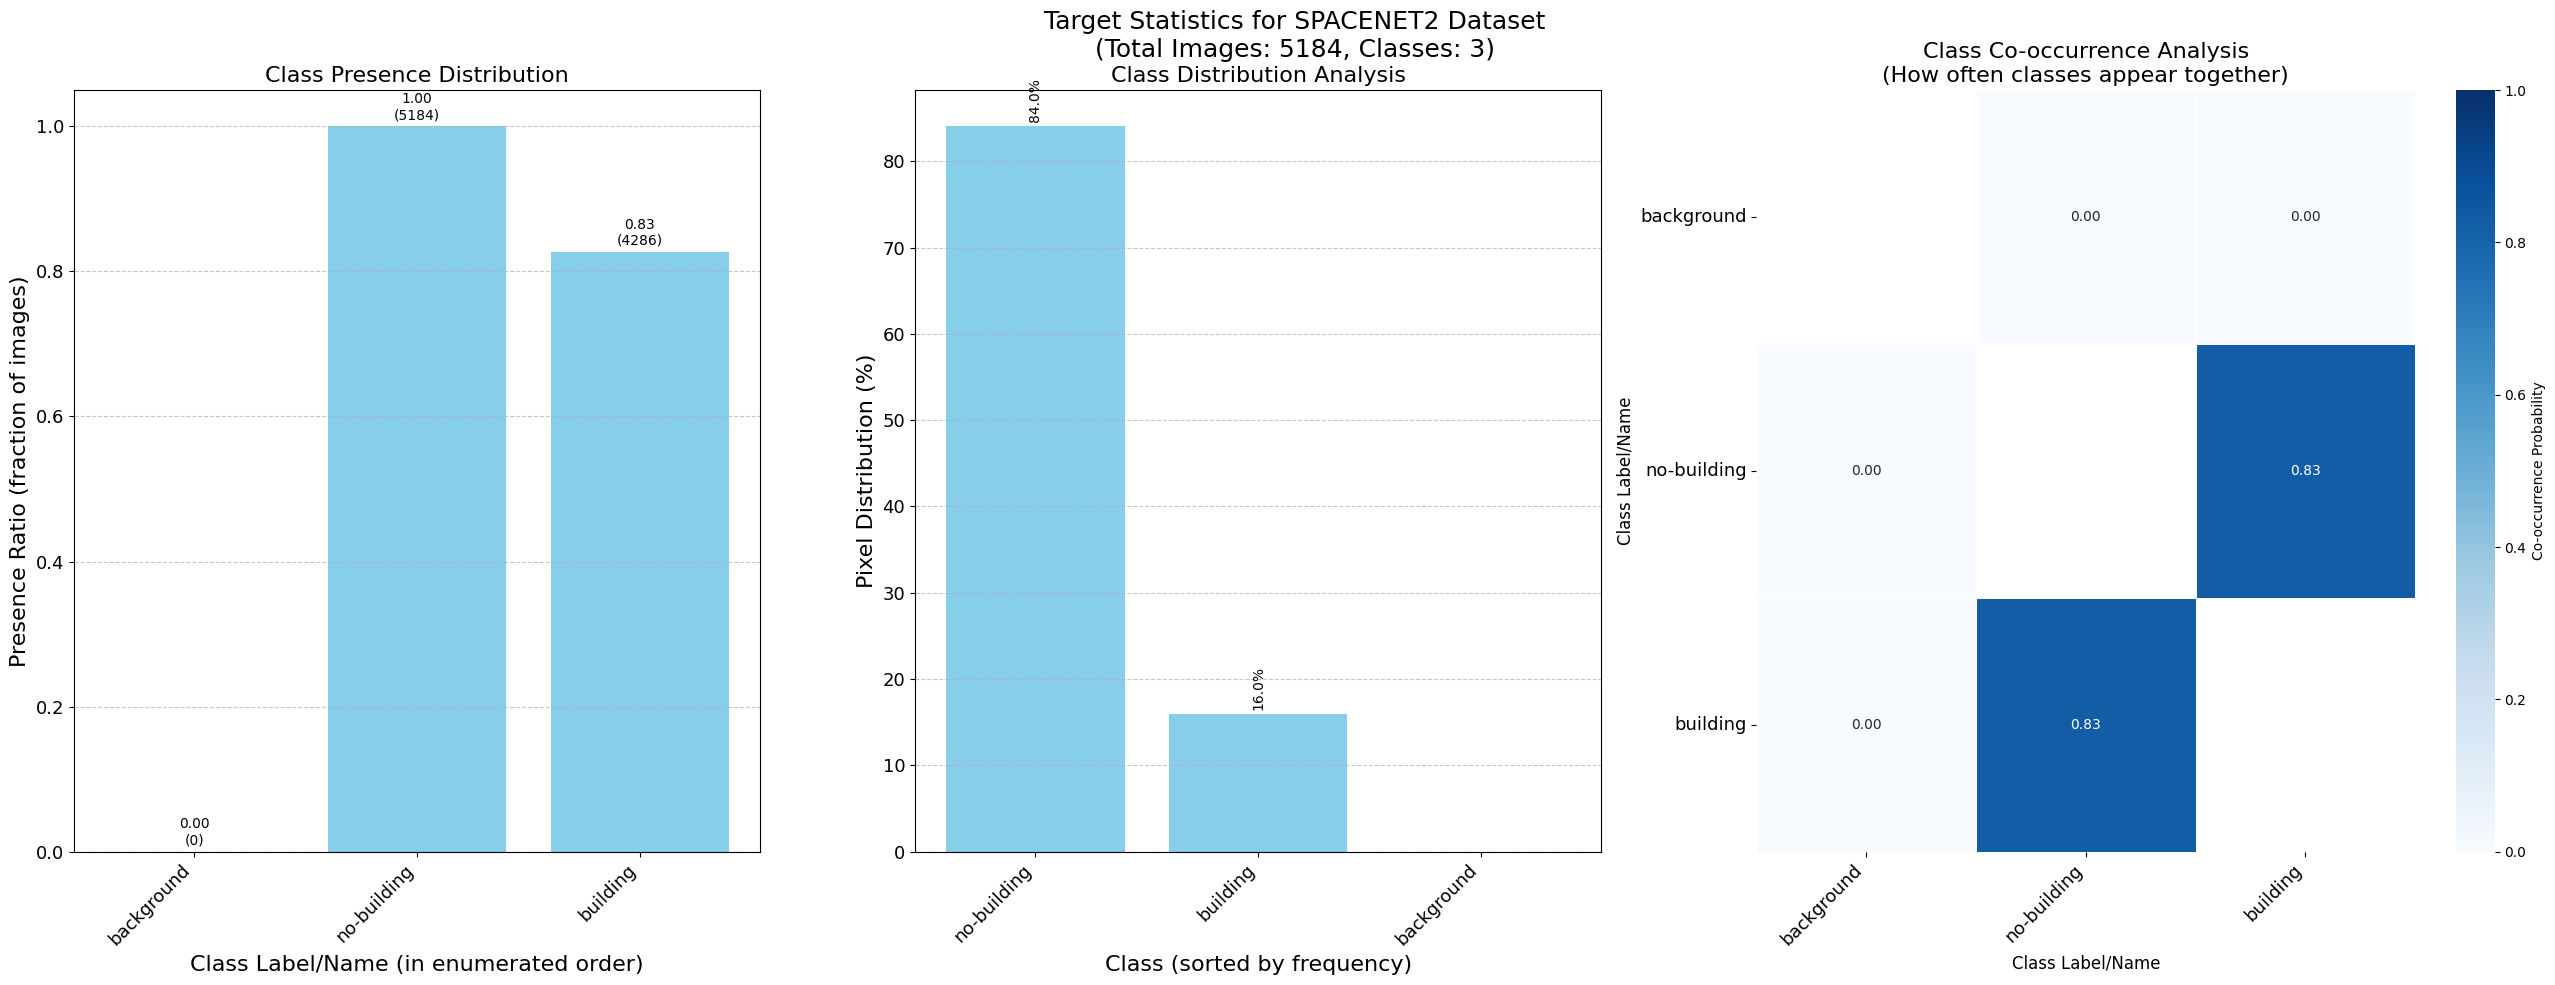

In [6]:
fig = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "SpaceNet2")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>, <Figure size 1200x500 with 1 Axes>]

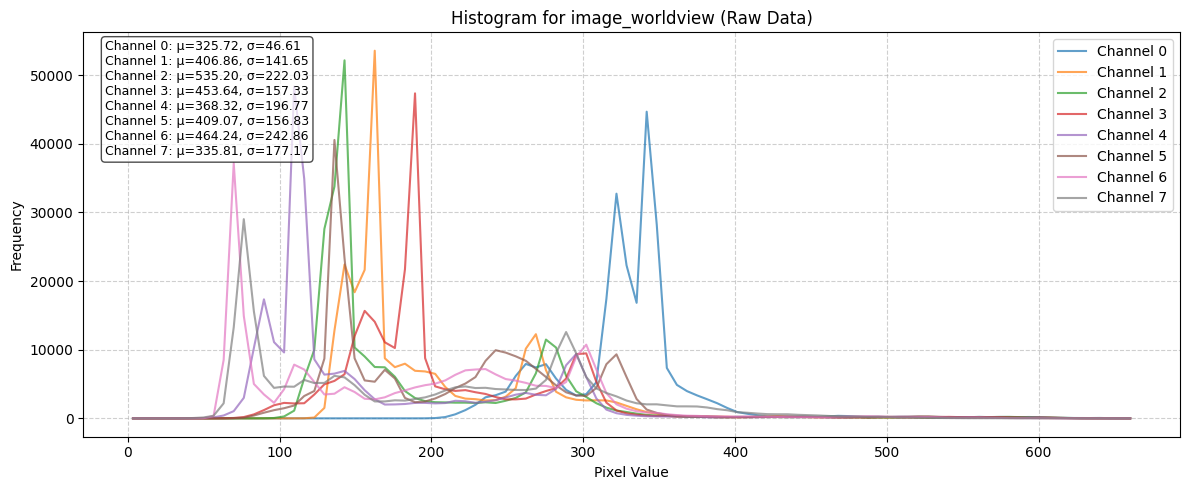

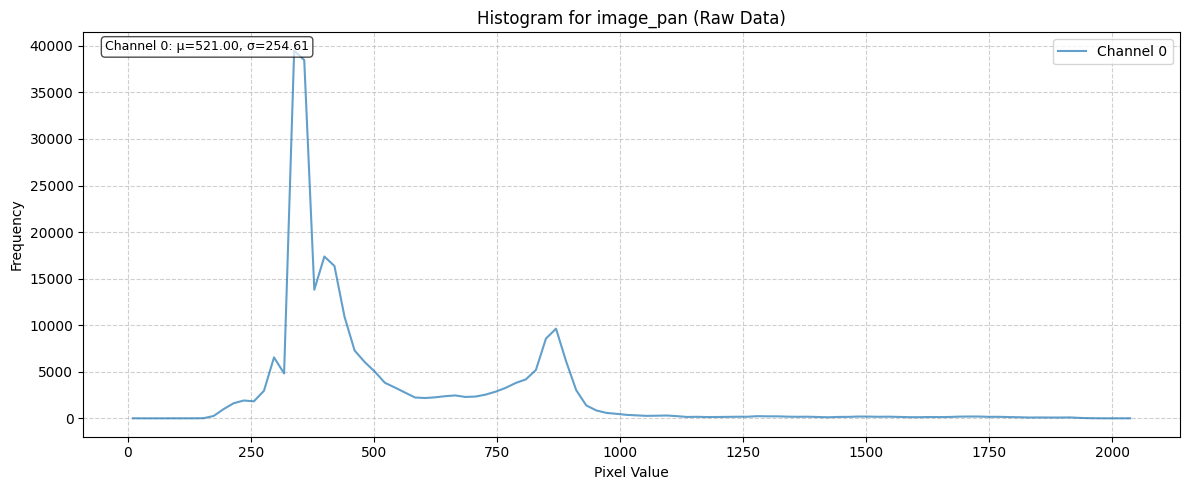

In [7]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

In [8]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

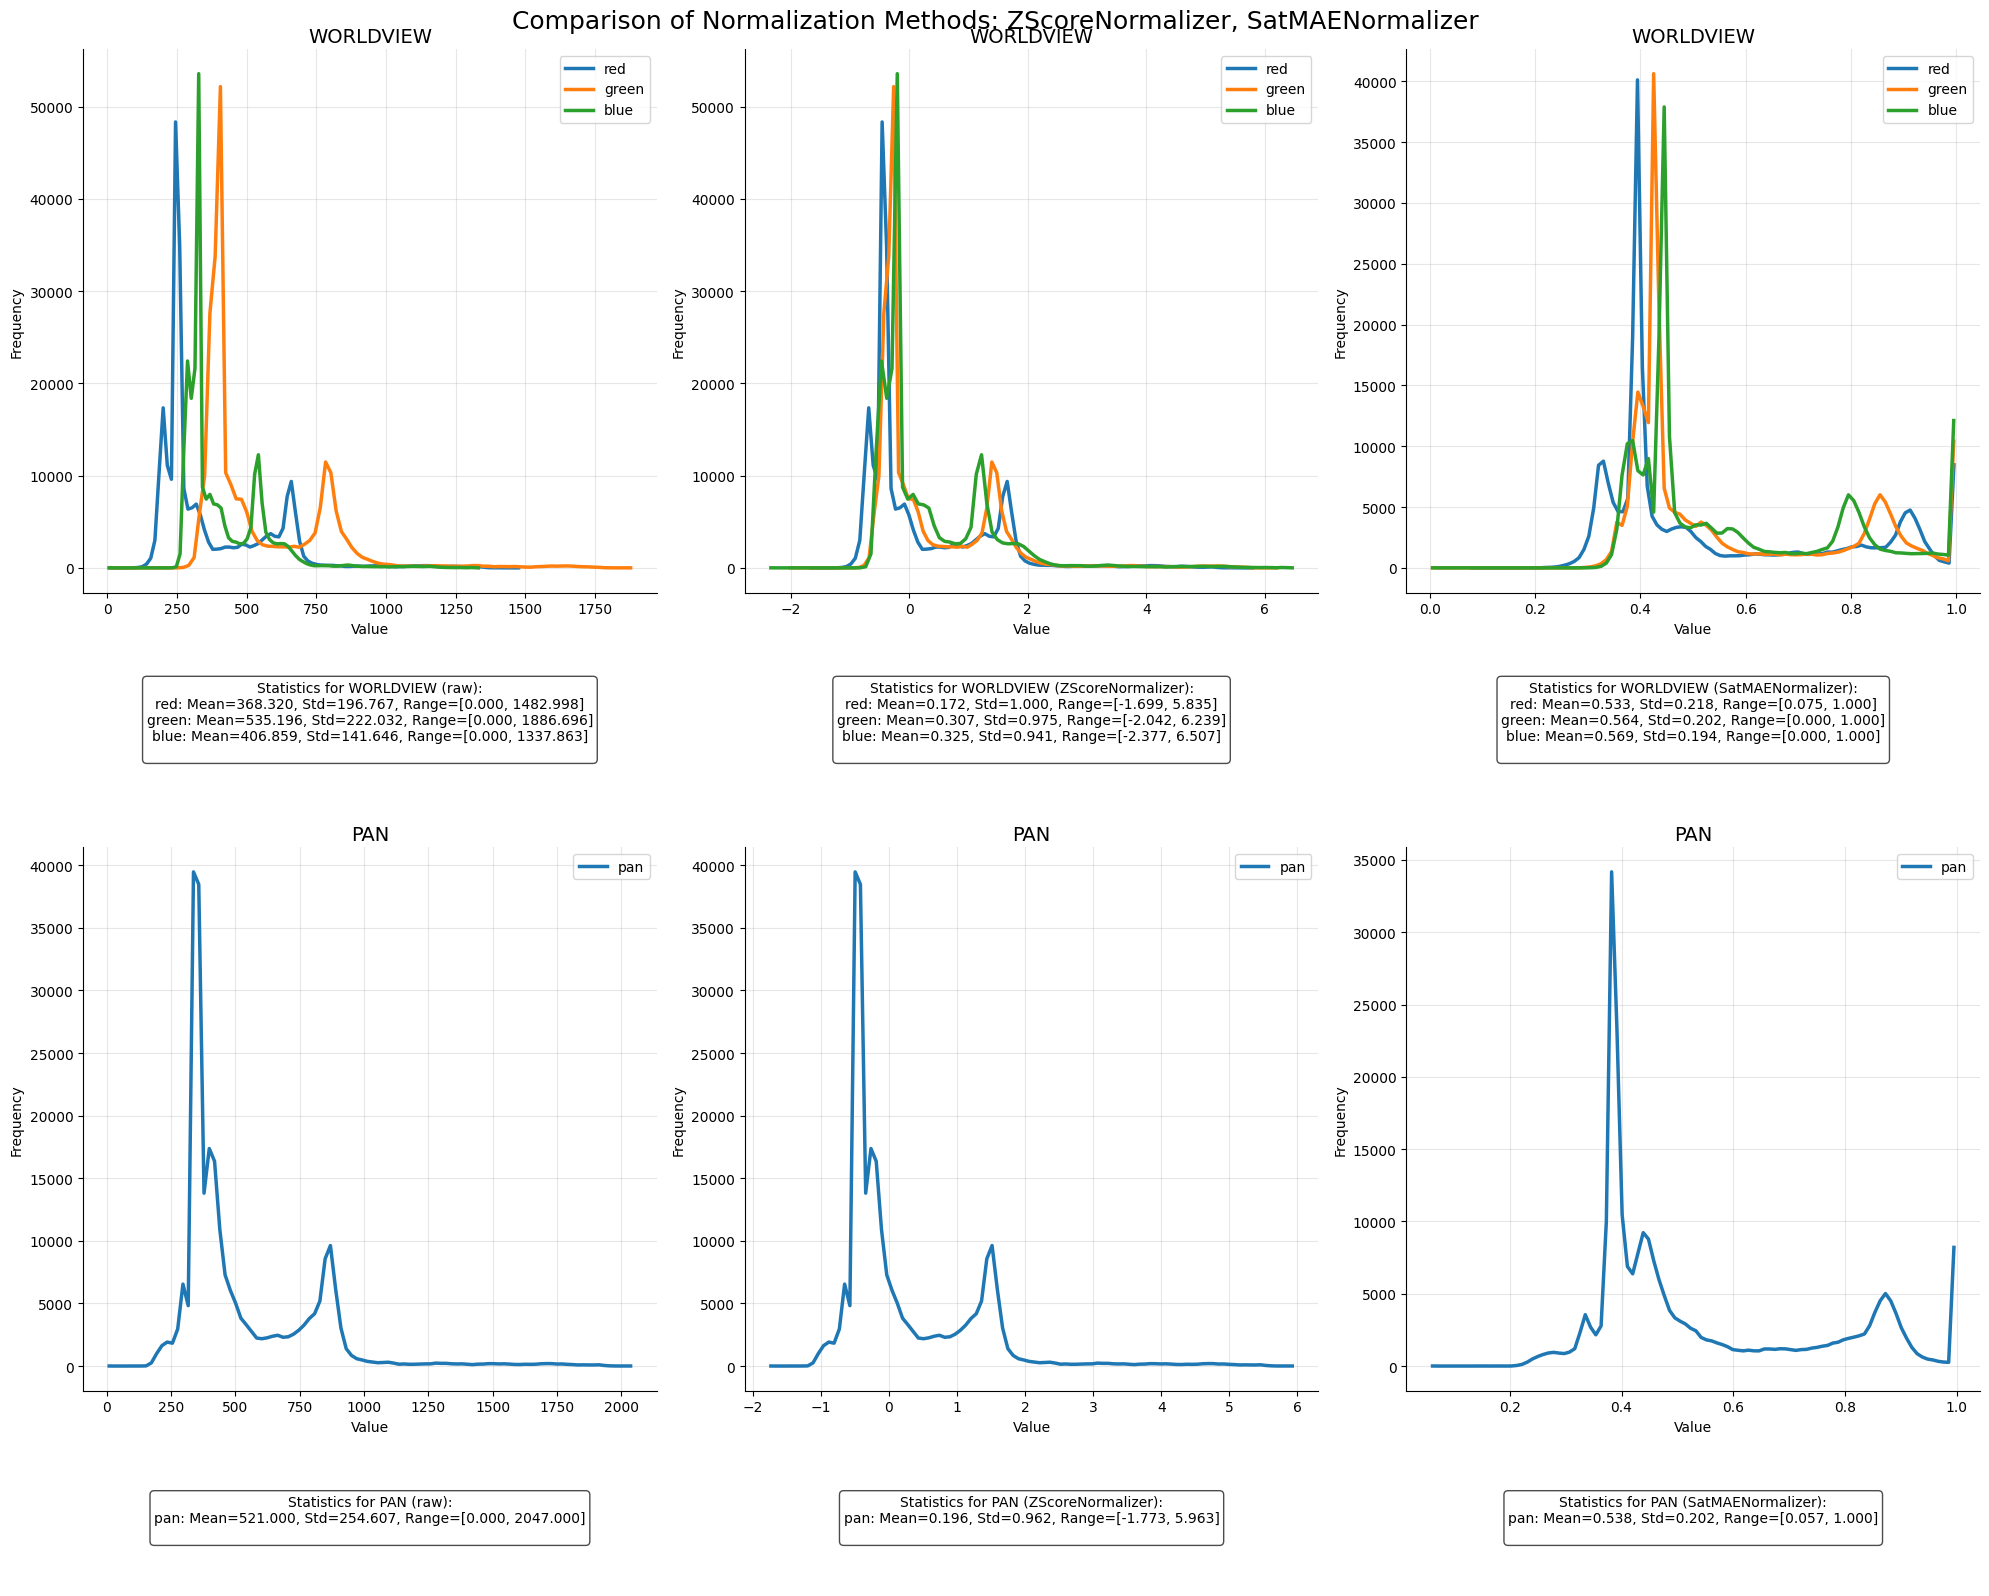

In [9]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch Data

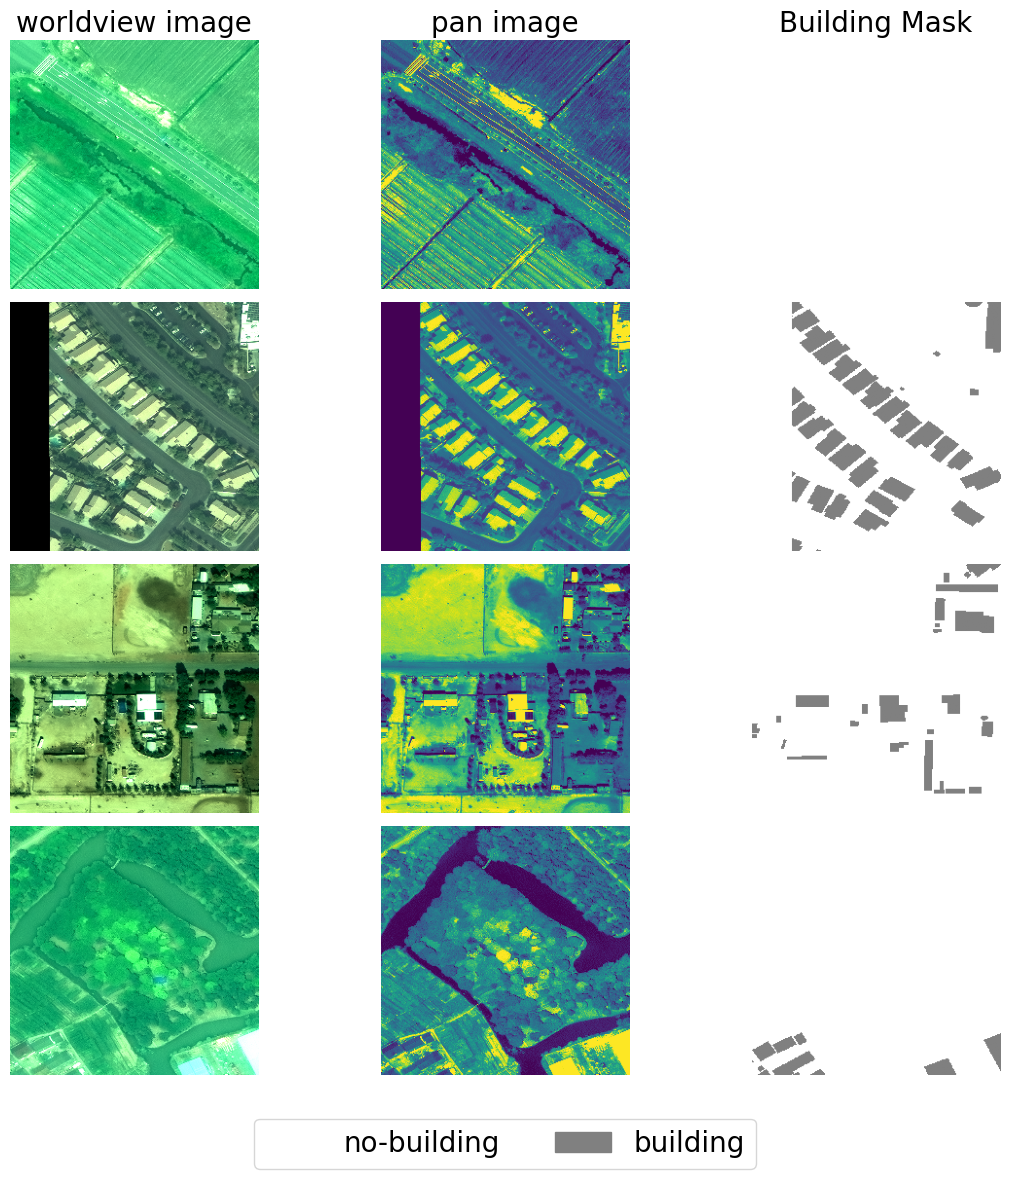

In [10]:
fig, batch = datamodule.visualize_batch()